In [1]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.171  Python-3.11.9 torch-2.14.1+cpu CPU (AMD Ryzen 7 7735HS with Radeon Graphics)


Setup complete  (16 CPUs, 31.2 GB RAM, 399.3/475.5 GB disk)


In [2]:
! nvidia-smi

Sun Oct  4 13:21:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.88                 KMD Version: 610.88        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   42C    P8              2W /   70W |       2MiB /   8188MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Import Data

In [3]:
# Import necessary libraries
import os
import requests
import tarfile
from tqdm import tqdm
     

In [4]:
yaml_content = """
  path: ./dataset
  train: images/train
  val: images/val
  nc: 8
  names: ["Car", "Motorcycle", "Bus", "Truck", "Tuktuk", "Van", "Pickup", "Songthaew"]
  """
with open("data.yaml", "w") as f:
      f.write(yaml_content)

## Step 2: Data Preprocessing — Convert `train.csv` to YOLO format

`train.csv` stores one row per bounding box in pixel corner coordinates
(`x1, y1, x2, y2`). YOLO (Ultralytics) instead expects, per image, a `.txt`
label file with one line per box:

```
class_id x_center y_center width height
```

all normalized to `[0, 1]` by image width/height, with images and labels
laid out as:

```
dataset/
  images/train/*.jpg
  images/val/*.jpg
  labels/train/*.txt
  labels/val/*.txt
```

which matches the `path`/`train`/`val` keys already written to `data.yaml`.

**Train/val split strategy:** the real test set (`test/test/`) comes from 5
camera locations that do **not** appear anywhere in `train/train/` (15
different cameras). To get a validation score that actually estimates
cross-camera generalization (instead of an optimistic same-camera score),
we hold out a few whole **cameras** from training rather than splitting
images randomly.

In [5]:
# --- Imports ---
import random
import shutil
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from tqdm import tqdm


In [6]:
# --- Paths & config ---
BASE_DIR = Path(".")
TRAIN_IMG_DIR = BASE_DIR / "train" / "train"
TEST_IMG_DIR = BASE_DIR / "test" / "test"
TRAIN_CSV = BASE_DIR / "train.csv"

DATASET_DIR = BASE_DIR / "dataset"
IMG_TRAIN_OUT = DATASET_DIR / "images" / "train"
IMG_VAL_OUT = DATASET_DIR / "images" / "val"
LBL_TRAIN_OUT = DATASET_DIR / "labels" / "train"
LBL_VAL_OUT = DATASET_DIR / "labels" / "val"

CLASS_NAMES = ["Car", "Motorcycle", "Bus", "Truck", "Tuktuk", "Van", "Pickup", "Songthaew"]

# Hold out these camera IDs for validation so val measures generalization to
# UNSEEN cameras -- matching how the real test set (different cameras) is scored.
# ~3 of the 15 train cameras (~500-600 images, roughly 15-20% of train).
VAL_CAMERA_IDS = {"172", "229", "1437"}

RANDOM_SEED = 42
random.seed(RANDOM_SEED)


In [7]:
# --- Load ground-truth boxes & derive camera id per image ---
df_train = pd.read_csv(TRAIN_CSV)
df_train["camera_id"] = df_train["image_id"].str.extract(r"^(\d+)_")

all_cameras = sorted(df_train["camera_id"].unique(), key=int)
print(f"Train cameras ({len(all_cameras)}):", all_cameras)
print("Held-out (val) cameras:", sorted(VAL_CAMERA_IDS, key=int))

missing = VAL_CAMERA_IDS - set(all_cameras)
assert not missing, f"VAL_CAMERA_IDS not found in train data: {missing}"


Train cameras (15): ['12', '172', '180', '182', '214', '222', '229', '231', '232', '244', '1066', '1407', '1426', '1427', '1437']
Held-out (val) cameras: ['172', '229', '1437']


In [8]:
# --- Split image ids by camera (not randomly by image) ---
all_image_ids = df_train["image_id"].unique().tolist()
image_camera = df_train.drop_duplicates("image_id").set_index("image_id")["camera_id"]

val_image_ids = [img for img in all_image_ids if image_camera[img] in VAL_CAMERA_IDS]
train_image_ids = [img for img in all_image_ids if image_camera[img] not in VAL_CAMERA_IDS]

n_train_boxes = df_train[df_train["image_id"].isin(train_image_ids)].shape[0]
n_val_boxes = df_train[df_train["image_id"].isin(val_image_ids)].shape[0]

print(f"Train images: {len(train_image_ids)}  |  Val images: {len(val_image_ids)}")
print(f"Train boxes:  {n_train_boxes}  |  Val boxes:  {n_val_boxes}")


Train images: 2297  |  Val images: 592
Train boxes:  23724  |  Val boxes:  3672


In [9]:
def to_yolo_format(x1, y1, x2, y2, img_w, img_h):
    """Convert pixel corner box (x1, y1, x2, y2) to normalized YOLO
    (x_center, y_center, width, height) in [0, 1]."""
    x_center = (x1 + x2) / 2.0 / img_w
    y_center = (y1 + y2) / 2.0 / img_h
    width = (x2 - x1) / img_w
    height = (y2 - y1) / img_h
    return (
        min(max(x_center, 0.0), 1.0),
        min(max(y_center, 0.0), 1.0),
        min(max(width, 0.0), 1.0),
        min(max(height, 0.0), 1.0),
    )


In [10]:
# --- Create output folder structure expected by data.yaml ---
for d in (IMG_TRAIN_OUT, IMG_VAL_OUT, LBL_TRAIN_OUT, LBL_VAL_OUT):
    d.mkdir(parents=True, exist_ok=True)


In [11]:
def build_split(image_ids, img_out_dir, lbl_out_dir, src_img_dir, df):
    """Copy images into img_out_dir and write one YOLO label .txt per
    image into lbl_out_dir (empty file if the image has no boxes)."""
    boxes_by_image = df.groupby("image_id")

    for image_id in tqdm(image_ids, desc=f"Processing {img_out_dir.name}"):
        src_path = src_img_dir / image_id
        dst_img_path = img_out_dir / image_id
        if not dst_img_path.exists():
            shutil.copy2(src_path, dst_img_path)

        with Image.open(src_path) as im:
            img_w, img_h = im.size

        label_lines = []
        if image_id in boxes_by_image.groups:
            for _, row in boxes_by_image.get_group(image_id).iterrows():
                xc, yc, w, h = to_yolo_format(row.x1, row.y1, row.x2, row.y2, img_w, img_h)
                label_lines.append(f"{int(row.class_id)} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}")

        label_path = lbl_out_dir / (Path(image_id).stem + ".txt")
        label_path.write_text("\n".join(label_lines), encoding="utf-8")


build_split(train_image_ids, IMG_TRAIN_OUT, LBL_TRAIN_OUT, TRAIN_IMG_DIR, df_train)
build_split(val_image_ids, IMG_VAL_OUT, LBL_VAL_OUT, TRAIN_IMG_DIR, df_train)

print("Done converting train.csv -> YOLO labels.")


Processing train:   0%|          | 0/2297 [00:00<?, ?it/s]

Processing train:   2%|▏         | 48/2297 [00:00<00:04, 478.93it/s]

Processing train:   5%|▍         | 114/2297 [00:00<00:03, 582.68it/s]

Processing train:   8%|▊         | 184/2297 [00:00<00:03, 634.16it/s]

Processing train:  11%|█         | 248/2297 [00:00<00:03, 614.46it/s]

...

Processing val:  63%|██████▎   | 374/592 [00:00<00:00, 845.22it/s]

Processing val:  79%|███████▊  | 465/592 [00:00<00:00, 866.02it/s]

Processing val:  93%|█████████▎| 553/592 [00:00<00:00, 845.34it/s]

Processing val: 100%|██████████| 592/592 [00:00<00:00, 772.47it/s]

Done converting train.csv -> YOLO labels.


images/train: 2297  labels/train: 2297
images/val:   592  labels/val:   592


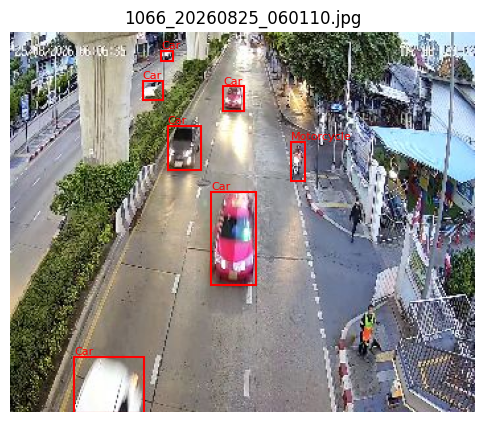

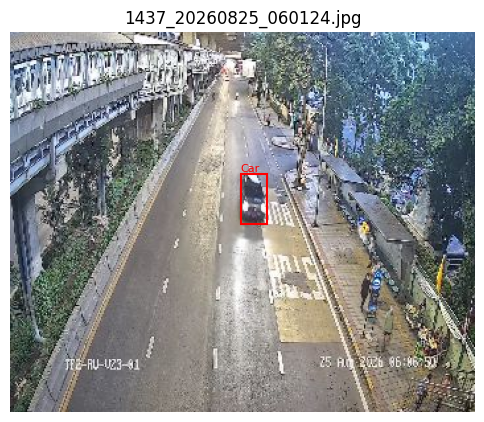

In [12]:
# --- Sanity check: counts + visualize a sample image with its converted boxes ---
n_train_imgs = len(list(IMG_TRAIN_OUT.iterdir()))
n_val_imgs = len(list(IMG_VAL_OUT.iterdir()))
n_train_lbls = len(list(LBL_TRAIN_OUT.iterdir()))
n_val_lbls = len(list(LBL_VAL_OUT.iterdir()))
print(f"images/train: {n_train_imgs}  labels/train: {n_train_lbls}")
print(f"images/val:   {n_val_imgs}  labels/val:   {n_val_lbls}")
assert n_train_imgs == n_train_lbls
assert n_val_imgs == n_val_lbls


def show_sample(image_id, img_dir, lbl_dir, class_names):
    img_path = img_dir / image_id
    lbl_path = lbl_dir / (Path(image_id).stem + ".txt")

    im = Image.open(img_path)
    img_w, img_h = im.size

    fig, ax = plt.subplots(1, figsize=(6, 5))
    ax.imshow(im)

    if lbl_path.exists():
        for line in lbl_path.read_text().splitlines():
            if not line.strip():
                continue
            cls, xc, yc, w, h = line.split()
            cls = int(cls)
            xc, yc = float(xc) * img_w, float(yc) * img_h
            w, h = float(w) * img_w, float(h) * img_h
            x1, y1 = xc - w / 2, yc - h / 2
            rect = patches.Rectangle((x1, y1), w, h, linewidth=1.5, edgecolor="red", facecolor="none")
            ax.add_patch(rect)
            ax.text(x1, max(y1 - 2, 0), class_names[cls], color="red", fontsize=8)

    ax.set_title(image_id)
    ax.axis("off")
    plt.show()


show_sample(train_image_ids[0], IMG_TRAIN_OUT, LBL_TRAIN_OUT, CLASS_NAMES)
show_sample(val_image_ids[0], IMG_VAL_OUT, LBL_VAL_OUT, CLASS_NAMES)


### Standalone reproducible preprocessing cell

Run the next cell by itself from the `2110531_mid_term` directory. It reads `train.csv`, converts the annotations to YOLO format, copies the images, and writes `dataset/data.yaml`.


In [13]:
# ============================================================
# Reproducible preprocessing: train.csv -> Ultralytics YOLO format
# Run this single cell from the 2110531_mid_term directory.
# ============================================================

from pathlib import Path
import re
import shutil

import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

# 1. Input and output paths
BASE_DIR = Path.cwd()
TRAIN_IMAGE_DIR = BASE_DIR / "train" / "train"
ANNOTATION_CSV = BASE_DIR / "train.csv"
YOLO_DIR = BASE_DIR / "dataset"

# Hold out complete cameras for validation. The test set uses different cameras,
# so this is a more realistic validation split than a random image split.
VAL_CAMERA_IDS = {"172", "229", "1437"}

CLASS_NAMES = [
    "Car", "Motorcycle", "Bus", "Truck",
    "Tuktuk", "Van", "Pickup", "Songthaew",
]

# Check that the notebook is being run from the correct folder.
assert TRAIN_IMAGE_DIR.exists(), f"Missing folder: {TRAIN_IMAGE_DIR}"
assert ANNOTATION_CSV.exists(), f"Missing file: {ANNOTATION_CSV}"

# 2. Read annotations and identify camera IDs
annotations = pd.read_csv(ANNOTATION_CSV)
required_columns = {"image_id", "class_id", "x1", "y1", "x2", "y2"}
missing_columns = required_columns - set(annotations.columns)
assert not missing_columns, f"Missing CSV columns: {missing_columns}"

annotations["camera_id"] = annotations["image_id"].str.extract(r"^(\d+)_")[0]

# 3. Use every train image, including images with zero annotations
image_paths = sorted(TRAIN_IMAGE_DIR.glob("*.jpg"))
assert image_paths, f"No .jpg images found in {TRAIN_IMAGE_DIR}"

image_ids = [path.name for path in image_paths]
image_camera = {
    image_id: re.match(r"^(\d+)_", image_id).group(1)
    for image_id in image_ids
}

missing_val_cameras = VAL_CAMERA_IDS - set(image_camera.values())
assert not missing_val_cameras, (
    f"Validation camera IDs not found in train images: {missing_val_cameras}"
)

train_image_ids = [
    image_id for image_id in image_ids
    if image_camera[image_id] not in VAL_CAMERA_IDS
]
val_image_ids = [
    image_id for image_id in image_ids
    if image_camera[image_id] in VAL_CAMERA_IDS
]

# 4. Prepare the Ultralytics folder structure
split_dirs = {
    "train": {
        "images": YOLO_DIR / "images" / "train",
        "labels": YOLO_DIR / "labels" / "train",
        "image_ids": train_image_ids,
    },
    "val": {
        "images": YOLO_DIR / "images" / "val",
        "labels": YOLO_DIR / "labels" / "val",
        "image_ids": val_image_ids,
    },
}

for split in split_dirs.values():
    split["images"].mkdir(parents=True, exist_ok=True)
    split["labels"].mkdir(parents=True, exist_ok=True)

# Group once so each image's boxes can be accessed efficiently.
boxes_by_image = annotations.groupby("image_id")

# 5. Convert pixel boxes to normalized YOLO boxes and write label files
# YOLO line format:
# class_id x_center y_center box_width box_height
for split_name, split in split_dirs.items():
    for image_id in tqdm(split["image_ids"], desc=f"Preparing {split_name}"):
        source_image = TRAIN_IMAGE_DIR / image_id
        destination_image = split["images"] / image_id
        shutil.copy2(source_image, destination_image)

        with Image.open(source_image) as image:
            image_width, image_height = image.size

        yolo_lines = []
        if image_id in boxes_by_image.groups:
            image_boxes = boxes_by_image.get_group(image_id)
            for row in image_boxes.itertuples(index=False):
                # Clip boxes to image boundaries before normalization.
                x1 = max(0.0, min(float(row.x1), image_width))
                y1 = max(0.0, min(float(row.y1), image_height))
                x2 = max(0.0, min(float(row.x2), image_width))
                y2 = max(0.0, min(float(row.y2), image_height))

                box_width = x2 - x1
                box_height = y2 - y1
                if box_width <= 0 or box_height <= 0:
                    continue

                x_center = ((x1 + x2) / 2.0) / image_width
                y_center = ((y1 + y2) / 2.0) / image_height
                normalized_width = box_width / image_width
                normalized_height = box_height / image_height

                yolo_lines.append(
                    f"{int(row.class_id)} "
                    f"{x_center:.6f} {y_center:.6f} "
                    f"{normalized_width:.6f} {normalized_height:.6f}"
                )

        label_path = split["labels"] / f"{Path(image_id).stem}.txt"
        label_path.write_text("\n".join(yolo_lines), encoding="utf-8")

# 6. Write/refresh the dataset configuration used by Ultralytics
DATA_YAML = YOLO_DIR / "data.yaml"
DATA_YAML.write_text(
    "\n".join([
        f"path: {YOLO_DIR.resolve().as_posix()}",
        "train: images/train",
        "val: images/val",
        f"nc: {len(CLASS_NAMES)}",
        f"names: {CLASS_NAMES}",
        "",
    ]),
    encoding="utf-8",
)

# 7. Verify that each copied image has a corresponding label file
for split_name, split in split_dirs.items():
    image_count = len(list(split["images"].glob("*.jpg")))
    label_count = len(list(split["labels"].glob("*.txt")))
    expected_count = len(split["image_ids"])
    assert image_count == expected_count, (split_name, image_count, expected_count)
    assert label_count == expected_count, (split_name, label_count, expected_count)

print("Preprocessing complete.")
print(f"Train images: {len(train_image_ids)}")
print(f"Validation images: {len(val_image_ids)}")
print(f"YOLO dataset config: {DATA_YAML}")
print(f"YOLO dataset directory: {YOLO_DIR.resolve()}")


Preparing train:   0%|          | 0/2387 [00:00<?, ?it/s]

Preparing val:   0%|          | 0/604 [00:00<?, ?it/s]

Preprocessing complete.
Train images: 2387
Validation images: 604
YOLO dataset config: C:\Users\Krisda Taveesak\Documents\python_vsc\master_project\2110531_DSDE_2026s1\2110531_mid_term\dataset\data.yaml
YOLO dataset directory: C:\Users\Krisda Taveesak\Documents\python_vsc\master_project\2110531_DSDE_2026s1\2110531_mid_term\dataset
